# HOMEWORK 13

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [1]:
# Import the required libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D, Dropout
from tensorflow.keras import Model
from time import time
from collections import Counter

# Import plotting utilities
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the random seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

D:\Computer_vision\tf311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train images: (50000, 32, 32, 3)
Test images:  (10000, 32, 32, 3)
Train labels: (50000,)
Test labels:  (10000,)


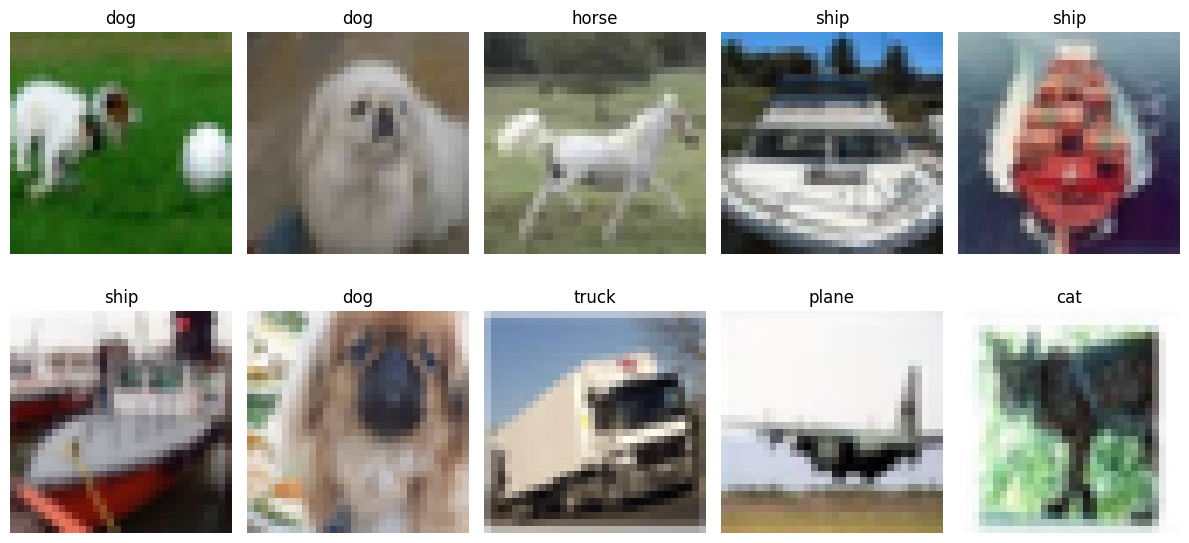

In [2]:
# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Convert labels from shape (N, 1) to shape (N,)
y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Create a mapping from class ID to class name
classes = {
    0: 'plane',
    1: 'car',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck',
}
num_classes = 10

# Print basic dataset information
print('Train images:', x_train.shape)
print('Test images: ', x_test.shape)
print('Train labels:', y_train.shape)
print('Test labels: ', y_test.shape)

# Show a few random training samples
plt.figure(figsize=(12, 6))
for i in range(10):
    idx = np.random.randint(0, len(x_train))
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx])
    plt.title(classes[y_train[idx]])
    plt.axis('off')
plt.tight_layout()
plt.show()

Compute the class histogram (you can visualize it if you want). Is the dataset balanced?

Hint: You might find [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) tool useful. In any case, it's up to you how you compute the histogram.

Train histogram:
plane: 5000
  car: 5000
 bird: 5000
  cat: 5000
 deer: 5000
  dog: 5000
 frog: 5000
horse: 5000
 ship: 5000
truck: 5000

Test histogram:
plane: 1000
  car: 1000
 bird: 1000
  cat: 1000
 deer: 1000
  dog: 1000
 frog: 1000
horse: 1000
 ship: 1000
truck: 1000


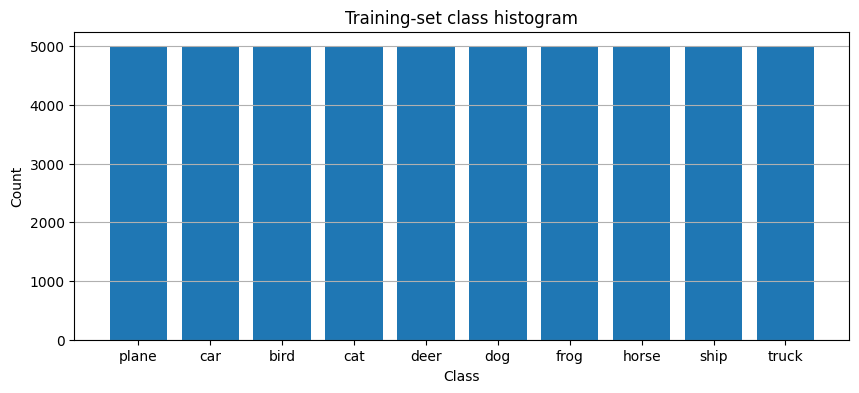

In [3]:
# Compute the class histogram for the sparse labels
hist_train = Counter(y_train)
hist_test = Counter(y_test)

print('Train histogram:')
for class_id, class_name in classes.items():
    print(f'{class_name:>5}: {hist_train[class_id]}')

print('\nTest histogram:')
for class_id, class_name in classes.items():
    print(f'{class_name:>5}: {hist_test[class_id]}')

# Visualize the class histogram
plt.figure(figsize=(10, 4))
plt.bar(range(num_classes), [hist_train[i] for i in range(num_classes)])
plt.xticks(range(num_classes), [classes[i] for i in range(num_classes)])
plt.title('Training-set class histogram')
plt.xlabel('Class')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show()

### Step 1: Data Preparation

In this step, you'll need to prepare the data for training, i.e., you will have to normalize it and encode the labels as one-hot vectors.

In [4]:
# Normalize image values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot vectors
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

# Print the prepared dataset shapes
print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [5]:
# Build a simple CNN classifier
inputs = Input(shape=x_train.shape[1:])  # (32, 32, 3)

# First convolution block
net = Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same')(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)

# Second convolution block
net = Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)

# Classification head
net = Flatten()(net)
outputs = Dense(num_classes, activation='softmax')(net)

# Create and summarize the model
model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          20,490 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,578 (99.91 KB)

 Trainable params: 25,578 (99.91 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training

Compile the model and train it.

In [6]:
# Set the training parameters
epochs = 25
batch_size = 128

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model and keep the history
t0 = time()
history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    verbose=1
)
print('Training time:', time() - t0, 'sec')

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4056 - loss: 1.6756 - val_accuracy: 0.4970 - val_loss: 1.4550
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5303 - loss: 1.3396 - val_accuracy: 0.5464 - val_loss: 1.3111
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5717 - loss: 1.2278 - val_accuracy: 0.5826 - val_loss: 1.2089
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5953 - loss: 1.1559 - val_accuracy: 0.6072 - val_loss: 1.1440
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6190 - loss: 1.0973 - val_accuracy: 0.6248 - val_loss: 1.0927
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6371 - loss: 1.0475 - val_accuracy: 0.6354 - val_loss: 1.0520
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6534 - loss: 1.0067 - val_accuracy: 0.6470 - val_loss: 1.0233
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6647 - loss: 0.9729 - val_accu

Train Acc      0.748533308506012
Validation Acc 0.6876000165939331


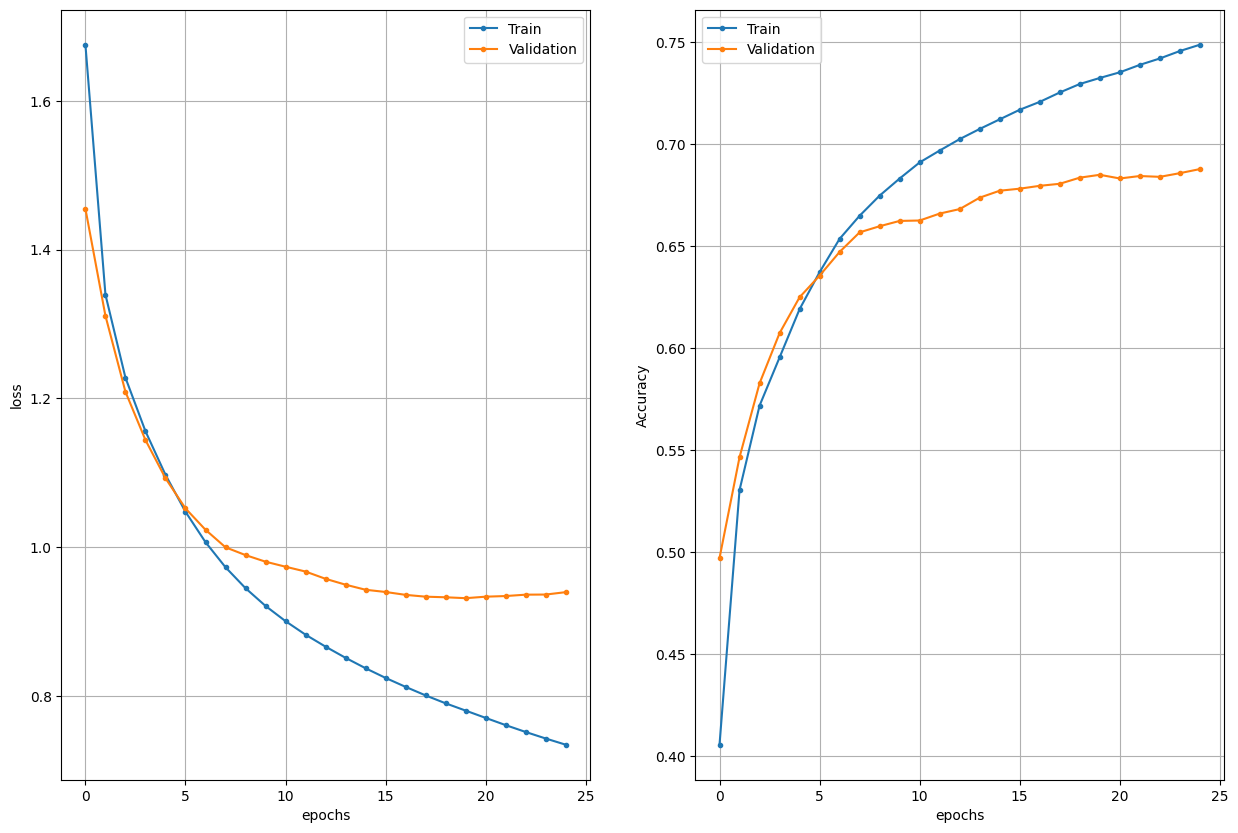

In [7]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])    

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

In [8]:
# Compute sparse true labels and predicted labels
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [9]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    mask = (y_true == class_id)
    acc = np.mean(y_pred[mask] == y_true[mask])
    print(class_name, acc)


plane 0.749
car 0.819
bird 0.601
cat 0.413
deer 0.703
dog 0.542
frog 0.794
horse 0.763
ship 0.642
truck 0.761


In [10]:
# Evaluate the baseline model on the test set
ev = model.evaluate(x_test, y_test, verbose=1)
baseline_test_loss = ev[0]
baseline_test_acc = ev[1]

print('Baseline test loss     ', baseline_test_loss)
print('Baseline test accuracy ', baseline_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6787 - loss: 0.9490
Baseline test loss      0.9489562511444092
Baseline test accuracy  0.6786999702453613


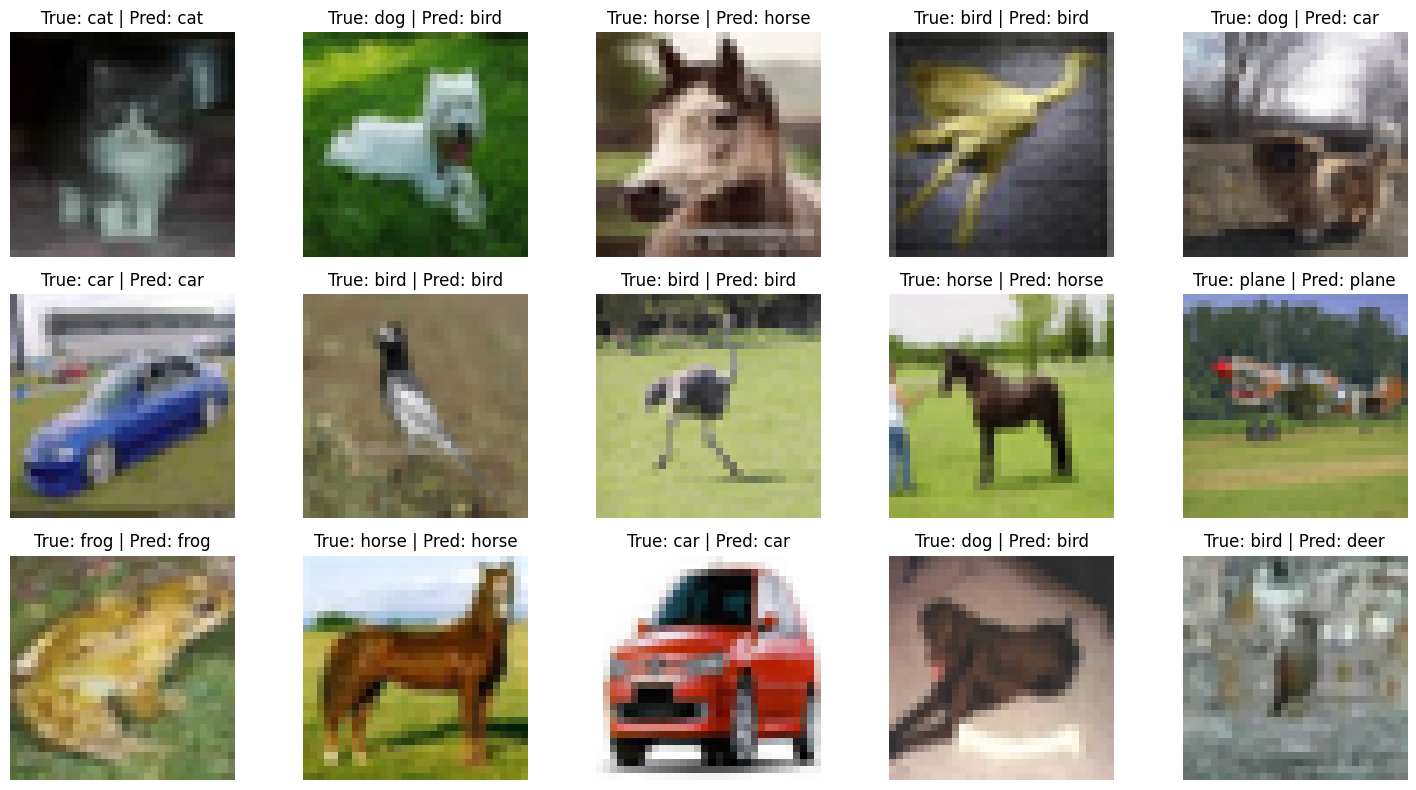

In [11]:
# Show random test samples with true and predicted labels
plt.figure(figsize=(15, 8))
for ii in range(15):
    idx = np.random.randint(0, len(x_test))
    plt.subplot(3, 5, ii + 1)
    plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))
    plt.axis('off')
plt.tight_layout()
plt.show()

### Step 5: Prediction Distribution Analysis

Use `Counter` to inspect how often the model predicts each class.

In [12]:
# Rebuild sparse labels to inspect the distribution after one-hot encoding
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

train_sparse = np.argmax(y_train, axis=1)
test_sparse = np.argmax(y_test, axis=1)

train_counts = Counter(train_sparse)
test_counts = Counter(test_sparse)

print('Train distribution:')
for cls in range(num_classes):
    print(f'{class_names[cls]}: {train_counts[cls]}')

print('\nTest distribution:')
for cls in range(num_classes):
    print(f'{class_names[cls]}: {test_counts[cls]}')

Train distribution:
airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000

Test distribution:
airplane: 1000
automobile: 1000
bird: 1000
cat: 1000
deer: 1000
dog: 1000
frog: 1000
horse: 1000
ship: 1000
truck: 1000


In [13]:
# Recompute predictions for the analysis cells below
y_pred_probs = model.predict(x_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [14]:
# Count how many times the model predicts each class
pred_counts = Counter(y_pred_labels)

print('Prediction distribution:')
for cls in range(num_classes):
    print(f'{class_names[cls]}: {pred_counts[cls]}')

Prediction distribution:
airplane: 1151
automobile: 1051
bird: 1152
cat: 751
deer: 1241
dog: 838
frog: 1103
horse: 1040
ship: 718
truck: 955


### Step 6: Error Analysis

Use `Counter` to inspect which true classes are misclassified most often and which wrong labels appear most often.

In [15]:
# Analyze the most common classification errors
wrong_mask = y_true != y_pred_labels

wrong_true_counts = Counter(y_true[wrong_mask])
wrong_pred_counts = Counter(y_pred_labels[wrong_mask])

print('Most frequently misclassified true classes:')
for cls, count in wrong_true_counts.most_common():
    print(f'{class_names[cls]}: {count}')

print('\nMost frequent wrong predictions:')
for cls, count in wrong_pred_counts.most_common():
    print(f'{class_names[cls]}: {count}')

Most frequently misclassified true classes:
cat: 587
dog: 458
bird: 399
ship: 358
deer: 297
airplane: 251
truck: 239
horse: 237
frog: 206
automobile: 181

Most frequent wrong predictions:
bird: 551
deer: 538
airplane: 402
cat: 338
frog: 309
dog: 296
horse: 277
automobile: 232
truck: 194
ship: 76


### Step 7: Improved Model

Try one simple modification that can help the model generalize better.  
Here, we add a `Dropout(0.3)` layer before the final dense layer to reduce overfitting.

In [16]:
# Import layers for functional API
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
# Build an improved CNN with Dropout
inputs2 = Input(shape=x_train.shape[1:])

net2 = Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same')(inputs2)
net2 = MaxPooling2D(pool_size=(2, 2))(net2)

net2 = Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')(net2)
net2 = MaxPooling2D(pool_size=(2, 2))(net2)

net2 = Flatten()(net2)
net2 = Dropout(0.3)(net2)
outputs2 = Dense(num_classes, activation='softmax')(net2)

model2 = Model(inputs2, outputs2)
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │          20,490 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,578 (99.91 KB)

 Trainable params: 25,578 (99.91 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Compile and train the improved model
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   # FIX: because y_train is one-hot
    metrics=['accuracy']
)

# Ensure epochs is integer
epochs = 25
batch_size = 128

t1 = time()

history2 = model2.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    verbose=1
)

print('Improved-model training time:', time() - t1, 'sec')

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3687 - loss: 1.7537 - val_accuracy: 0.4680 - val_loss: 1.5200
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4894 - loss: 1.4405 - val_accuracy: 0.5164 - val_loss: 1.3773
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5339 - loss: 1.3201 - val_accuracy: 0.5616 - val_loss: 1.2602
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5639 - loss: 1.2466 - val_accuracy: 0.5914 - val_loss: 1.1806
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5809 - loss: 1.1931 - val_accuracy: 0.6124 - val_loss: 1.1268
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5999 - loss: 1.1474 - val_accuracy: 0.6258 - val_loss: 1.0902
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6133 - loss: 1.1136 - val_accuracy: 0.6344 - val_loss: 1.0625
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6251 - loss: 1.0790 - val_accu

In [18]:
# Evaluate the improved model
ev2 = model2.evaluate(x_test, y_test, verbose=1)
improved_test_loss = ev2[0]
improved_test_acc = ev2[1]

print('Improved test loss     ', improved_test_loss)
print('Improved test accuracy ', improved_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6913 - loss: 0.8930
Improved test loss      0.8929629921913147
Improved test accuracy  0.6912999749183655


### Final Answers

The cell below prints short answers to the homework questions directly from the computed metrics.

In [19]:
# Print short answers to the homework questions
print(f'1) Overall accuracy of the baseline classifier: {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)')

print('\n2) Possible ways to improve the classification accuracy:')
print('- add more convolutional layers')
print('- increase the number of filters')
print('- use Dropout and/or BatchNormalization')
print('- train longer or tune the learning rate')
print('- use data augmentation')

print('\n3) One modification used here: Dropout(0.3) before the final dense layer.')
print(f'   Baseline accuracy: {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)')
print(f'   Improved accuracy: {improved_test_acc:.4f} ({improved_test_acc*100:.2f}%)')

if improved_test_acc > baseline_test_acc:
    print('   Result: yes, the accuracy improved.')
elif improved_test_acc < baseline_test_acc:
    print('   Result: no, the accuracy did not improve.')
else:
    print('   Result: the accuracy stayed the same.')

1) Overall accuracy of the baseline classifier: 0.6787 (67.87%)

2) Possible ways to improve the classification accuracy:
- add more convolutional layers
- increase the number of filters
- use Dropout and/or BatchNormalization
- train longer or tune the learning rate
- use data augmentation

3) One modification used here: Dropout(0.3) before the final dense layer.
   Baseline accuracy: 0.6787 (67.87%)
   Improved accuracy: 0.6913 (69.13%)
   Result: yes, the accuracy improved.
